In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    balanced_accuracy_score,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score
)
from sklearn.base import clone

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")


In [2]:
#Plotting settings
sns.set_theme(style="whitegrid", font_scale=1.05)

FIGSIZE_PANEL = (15, 12)
FIGSIZE_MAIN = (8, 5)

COLOR_NEGATIVE = "#4C72B0"
COLOR_POSITIVE = "#C44E52"

CHAGAS_PALETTE = {
    "Negative": COLOR_NEGATIVE,
    "Positive": COLOR_POSITIVE
}


 ## 1. Load Data

In [3]:
df = pd.read_csv("new_df.csv")

target_col = "chagas"

X = df.drop(columns=[target_col])
y = df[target_col]
groups = df["patient_id"]

print("Dataset size:", df.shape)

print("\nTarget variable distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True))


Dataset size: (342142, 42)

Target variable distribution:
chagas
0    335583
1      6559
Name: count, dtype: int64

Target proportions:
chagas
0    0.98083
1    0.01917
Name: proportion, dtype: float64


 ## 2. Train / Validation / Test Split by Patient

In [4]:
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_temp = X.iloc[temp_idx].copy()

y_train = y.iloc[train_idx].copy()
y_temp = y.iloc[temp_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_temp = groups.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(X_temp, y_temp, groups=groups_temp)
)

X_val = X_temp.iloc[val_idx].copy()
X_test = X_temp.iloc[test_idx].copy()

y_val = y_temp.iloc[val_idx].copy()
y_test = y_temp.iloc[test_idx].copy()

groups_val = groups_temp.iloc[val_idx].copy()
groups_test = groups_temp.iloc[test_idx].copy()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (239583, 41)
Validation: (51312, 41)
Test: (51247, 41)


In [5]:
train_patients = set(groups_train)
val_patients = set(groups_val)
test_patients = set(groups_test)

print("Train-Val overlap:", len(train_patients & val_patients))
print("Train-Test overlap:", len(train_patients & test_patients))
print("Val-Test overlap:", len(val_patients & test_patients))



Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [6]:
#Target class balance across splits
print(f"Train positive rate: {y_train.mean():.4f} ({y_train.sum()}/{len(y_train)})")
print(f"Validation positive rate: {y_val.mean():.4f} ({y_val.sum()}/{len(y_val)})")
print(f"Test positive rate: {y_test.mean():.4f} ({y_test.sum()}/{len(y_test)})")


Train positive rate: 0.0186 (4450/239583)
Validation positive rate: 0.0218 (1120/51312)
Test positive rate: 0.0193 (989/51247)


 ## 3. Basic Preprocessing and Feature Groups

In [7]:
drop_model_cols = [
    "exam_id",
    "patient_id",
    "interval_lead_idx",
    "n_usable_leads"
]

drop_model_cols = [
    col for col in drop_model_cols
    if col in X_train.columns
]

X_train = X_train.drop(columns=drop_model_cols)
X_val = X_val.drop(columns=drop_model_cols)
X_test = X_test.drop(columns=drop_model_cols)

for data_part in [X_train, X_val, X_test]:
    bool_cols = data_part.select_dtypes(include=["bool"]).columns
    data_part[bool_cols] = data_part[bool_cols].astype(int)

object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

if len(object_cols) > 0:
    print("Object columns detected:")
    print(object_cols)
    raise ValueError("Object columns must be encoded before logistic regression.")
else:
    print("No object columns detected.")


No object columns detected.


In [8]:
all_numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

binary_cols = [
    col for col in [
        "is_male",
        "RBBB",
        "LBBB",
        "1dAVb",
        "AF",
        "SB",
        "ST",
        "normal_ecg"
    ]
    if col in X_train.columns
]

continuous_cols = [
    col for col in all_numeric_cols
    if col not in binary_cols
]

print(f"All numeric columns: {len(all_numeric_cols)}")
print(f"Continuous columns: {len(continuous_cols)}")
print(f"Binary / indicator columns: {len(binary_cols)}")

print("\nBinary columns:")
print(binary_cols)

print("\nContinuous columns:")
print(continuous_cols)


All numeric columns: 37
Continuous columns: 30
Binary / indicator columns: 7

Binary columns:
['is_male', 'RBBB', 'LBBB', '1dAVb', 'AF', 'SB', 'ST']

Continuous columns:
['peak_count_mean', 'peak_count_std', 'rr_mean_mean', 'rr_mean_std', 'rr_std_mean', 'rr_std_std', 'hrv_rmssd_mean', 'hrv_rmssd_std', 'total_power_mean', 'total_power_std', 'dominant_frequency_mean', 'dominant_frequency_std', 'energy_approx_mean', 'energy_approx_std', 'energy_detail_1_mean', 'energy_detail_1_std', 'energy_detail_2_mean', 'energy_detail_2_std', 'energy_detail_3_mean', 'energy_detail_3_std', 'energy_detail_4_mean', 'energy_detail_4_std', 'energy_detail_5_mean', 'energy_detail_5_std', 'pr_interval', 'qrs_duration', 'qt_interval', 'sdnn', 'pnn50', 'age']


 ## 4. Check Negative Values

In [9]:
negative_summary = []

for col in continuous_cols:
    min_value = X_train[col].min(skipna=True)

    negative_summary.append({
        "Feature": col,
        "Min value": min_value,
        "Has negative values": min_value < 0
    })

negative_summary_df = (
    pd.DataFrame(negative_summary)
    .sort_values("Min value")
    .reset_index(drop=True)
)

display(negative_summary_df)


,Feature,Min value,Has negative values
0,peak_count_std,0.000000,False
1,rr_mean_std,0.000000,False
2,rr_std_std,0.000000,False
3,rr_std_mean,0.000000,False
4,hrv_rmssd_std,0.000000,False
5,dominant_frequency_std,0.000000,False
6,sdnn,0.000000,False
7,pnn50,0.000000,False
8,energy_detail_5_std,0.000068,False
9,energy_detail_5_mean,0.000150,False


 ## 5. Missing Values Before Modelling

In [10]:
missing_train = X_train[all_numeric_cols].isna().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Feature": missing_train.index,
    "Missing values": missing_train.values,
    "Missing proportion (%)": missing_train.values / len(X_train) * 100
})

display(missing_df)


,Feature,Missing values,Missing proportion (%)
0,qrs_duration,1187,0.495444
1,qt_interval,1165,0.486262
2,pr_interval,714,0.298018
3,hrv_rmssd_std,58,0.024209
4,hrv_rmssd_mean,14,0.005843
5,rr_mean_std,13,0.005426
6,rr_std_std,13,0.005426
7,sdnn,10,0.004174
8,pnn50,10,0.004174
9,rr_std_mean,8,0.003339


 ## 6. Skewness and Log1p Transformation

In [11]:
skewness_before = (
    X_train[continuous_cols]
    .skew()
    .sort_values(ascending=False)
)

skew_threshold = 1.0

skewed_cols = (
    skewness_before[skewness_before.abs() > skew_threshold]
    .index
    .tolist()
)

print(f"Continuous columns with absolute skewness > 1:")
print(skewed_cols)


Continuous columns with absolute skewness > 1:
['rr_mean_std', 'energy_detail_5_std', 'energy_detail_5_mean', 'hrv_rmssd_std', 'energy_detail_4_mean', 'peak_count_std', 'rr_std_std', 'hrv_rmssd_mean', 'energy_detail_4_std', 'rr_std_mean', 'sdnn', 'energy_approx_std', 'total_power_std', 'energy_detail_3_mean', 'energy_detail_3_std', 'rr_mean_mean', 'pnn50', 'dominant_frequency_mean', 'qrs_duration', 'total_power_mean']


In [12]:
X_train_transformed = X_train.copy()
X_val_transformed = X_val.copy()
X_test_transformed = X_test.copy()

for col in skewed_cols:
    X_train_transformed[col] = np.log1p(X_train_transformed[col])
    X_val_transformed[col] = np.log1p(X_val_transformed[col])
    X_test_transformed[col] = np.log1p(X_test_transformed[col])

skewness_after = (
    X_train_transformed[continuous_cols]
    .skew()
    .sort_values(ascending=False)
)

skewness_comparison = pd.DataFrame({
    "Feature": continuous_cols,
    "Skewness before": skewness_before.reindex(continuous_cols).values,
    "Skewness after": skewness_after.reindex(continuous_cols).values,
    "Transformed": [col in skewed_cols for col in continuous_cols]
}).sort_values("Skewness before", ascending=False)

display(skewness_comparison.round(3))


,Feature,Skewness before,Skewness after,Transformed
3,rr_mean_std,11.739,0.764,True
23,energy_detail_5_std,8.807,4.772,True
22,energy_detail_5_mean,7.832,4.528,True
7,hrv_rmssd_std,6.175,0.054,True
20,energy_detail_4_mean,5.809,-0.212,True
1,peak_count_std,4.917,1.834,True
5,rr_std_std,4.236,0.178,True
6,hrv_rmssd_mean,4.087,0.330,True
21,energy_detail_4_std,4.039,0.497,True
4,rr_std_mean,3.197,0.228,True


 ## 7. Histograms Before and After Transformation

In [13]:
hist_features = [
    "peak_count_mean",
    "rr_mean_mean",
    "rr_std_mean",
    "hrv_rmssd_mean",
    "pr_interval",
    "qrs_duration",
    "qt_interval",
    "total_power_mean",
    "dominant_frequency_mean",
]

hist_features = [
    col for col in hist_features
    if col in X_train.columns
]


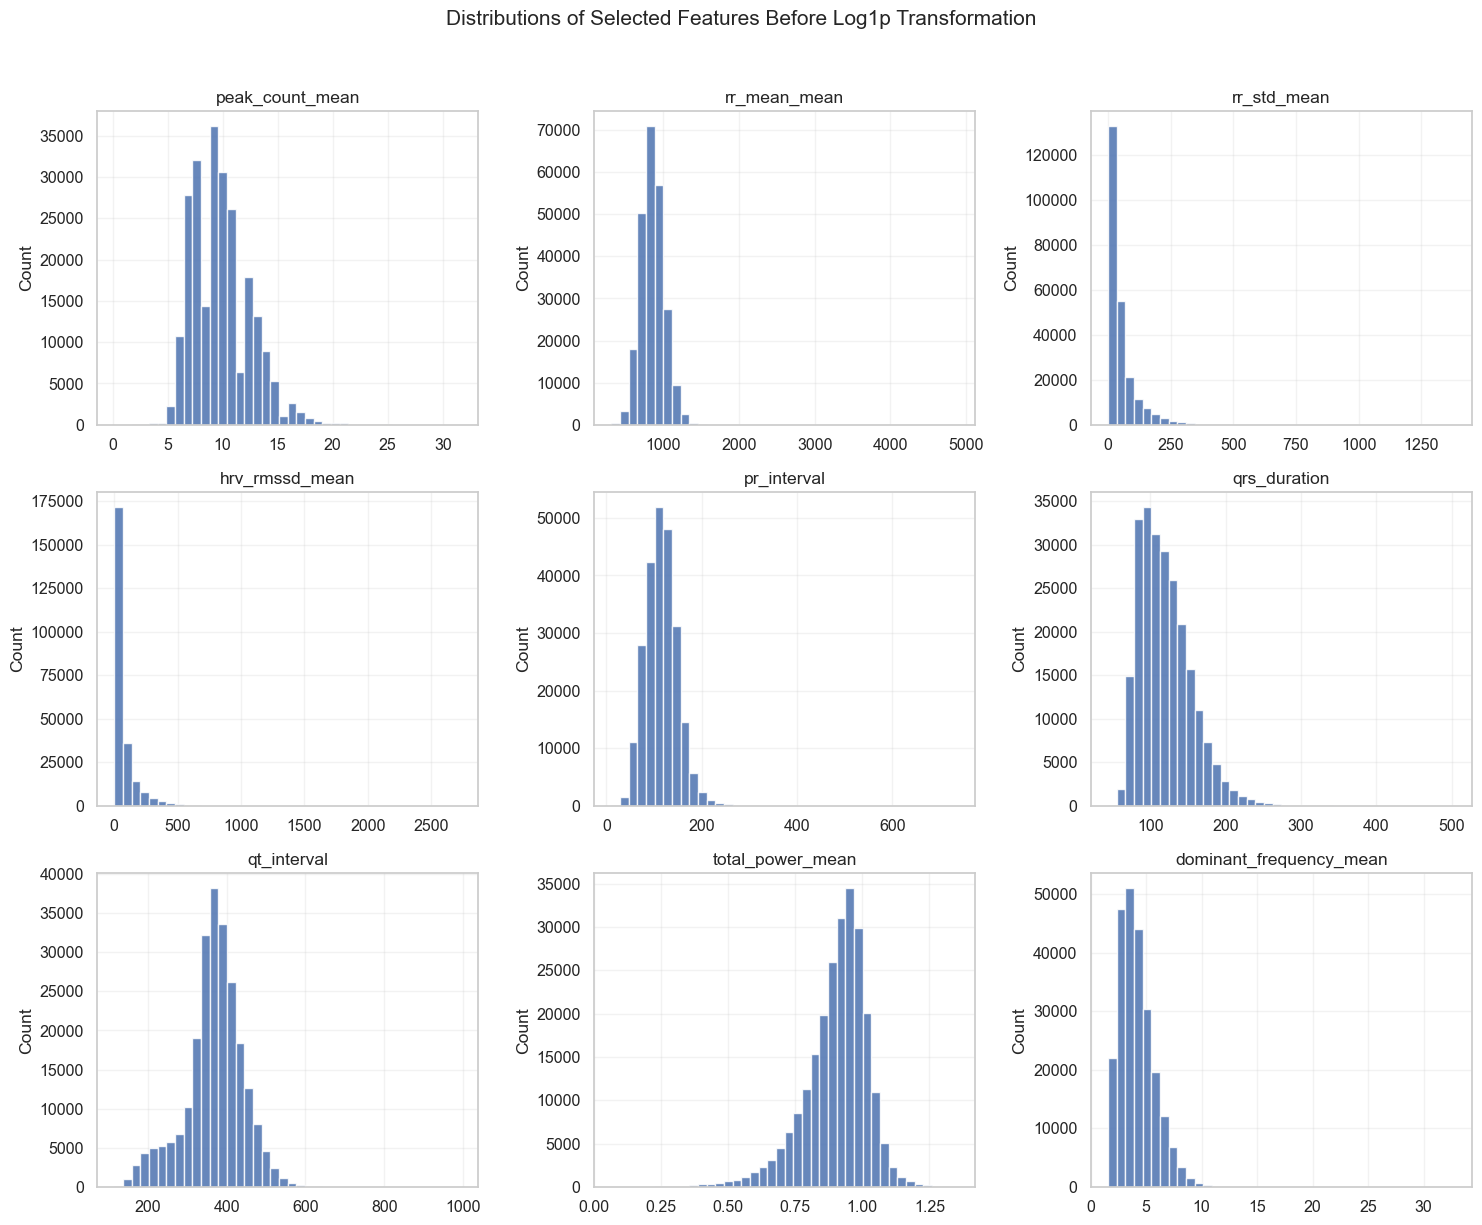

In [14]:
#Before transformation
fig, axes = plt.subplots(3, 3, figsize=FIGSIZE_PANEL)
axes = axes.flatten()

for ax, feat in zip(axes, hist_features):
    values = X_train[feat].dropna()

    ax.hist(values, bins=40, color="#4C72B0", alpha=0.85)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)

for ax in axes[len(hist_features):]:
    ax.set_visible(False)

plt.suptitle(
    "Distributions of Selected Features Before Log1p Transformation",
    y=1.02,
    fontsize=15
)

plt.tight_layout()
plt.show()


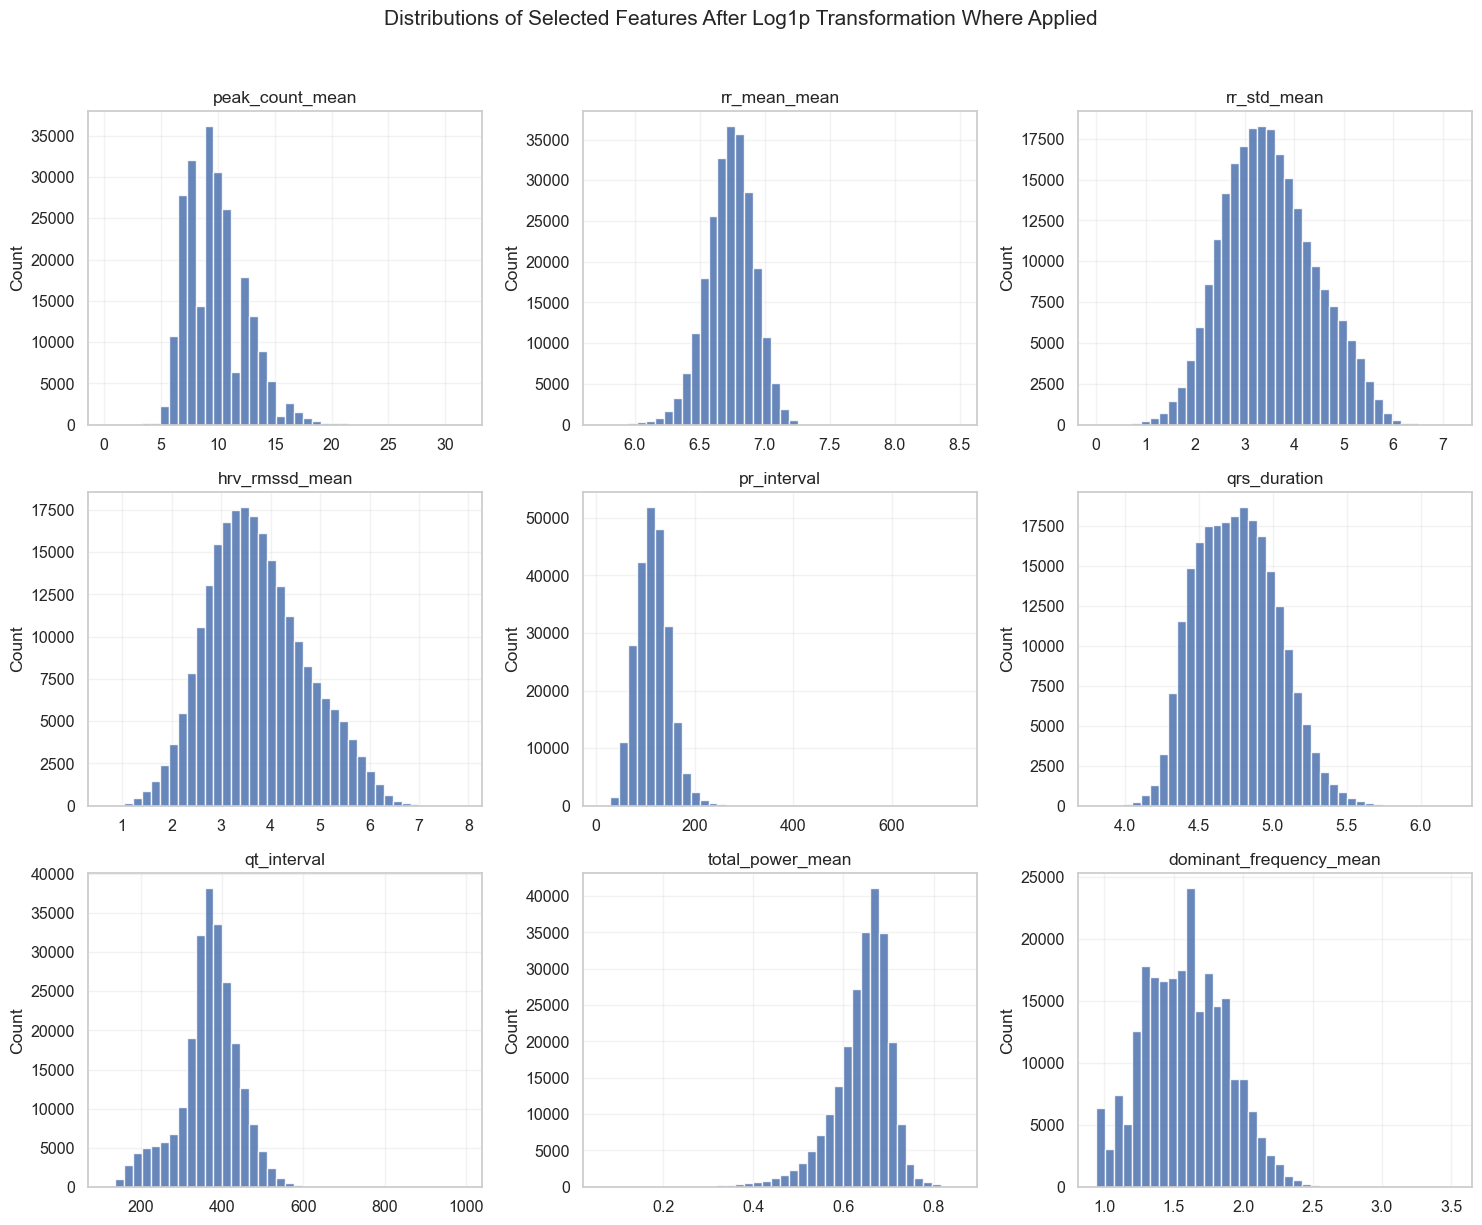

In [15]:
#After transformation
fig, axes = plt.subplots(3, 3, figsize=FIGSIZE_PANEL)
axes = axes.flatten()

for ax, feat in zip(axes, hist_features):
    values = X_train_transformed[feat].dropna()

    ax.hist(values, bins=40, color="#4C72B0", alpha=0.85)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)

for ax in axes[len(hist_features):]:
    ax.set_visible(False)

plt.suptitle(
    "Distributions of Selected Features After Log1p Transformation Where Applied",
    y=1.02,
    fontsize=15
)

plt.tight_layout()
plt.show()


 ## 8. Outlier Summary After Transformation

In [16]:
def get_outlier_summary(data, columns):
    outlier_summary = []

    for col in columns:
        x = data[col].dropna()

        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = (data[col] < lower) | (data[col] > upper)

        outlier_summary.append({
            "Feature": col,
            "Lower bound": lower,
            "Upper bound": upper,
            "Outliers": outliers.sum(),
            "Outlier proportion (%)": outliers.mean() * 100
        })

    return (
        pd.DataFrame(outlier_summary)
        .sort_values("Outlier proportion (%)", ascending=False)
        .reset_index(drop=True)
    )

outlier_summary_after = get_outlier_summary(
    X_train_transformed,
    continuous_cols
)

display(outlier_summary_after.head(15).round(3))


,Feature,Lower bound,Upper bound,Outliers,Outlier proportion (%)
0,total_power_std,-0.047,0.163,14699,6.135
1,energy_detail_5_std,-0.018,0.061,13705,5.720
2,qt_interval,217.188,529.688,13630,5.689
3,energy_detail_3_mean,3.889,6.284,11071,4.621
4,total_power_mean,0.506,0.789,9986,4.168
5,peak_count_std,-0.493,0.822,9009,3.760
6,energy_detail_5_mean,-0.021,0.094,7383,3.082
7,peak_count_mean,3.250,15.917,6427,2.683
8,energy_detail_2_mean,180.816,1384.540,5700,2.379
9,energy_detail_3_std,2.812,5.735,5104,2.130


 ## 9. VIF-Based Feature Selection
 *In the final model, this wasn't applied, since l2 regularization solves that. The threshold is set to huge value so any features wouldn't be removed.

In [17]:
model_cols = continuous_cols + binary_cols

vif_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cols_to_keep = model_cols.copy()
vif_threshold = 60
iteration = 0
dropped_features = []

while True:
    iteration += 1

    temp_transformer = ColumnTransformer(
        transformers=[
            ("num", vif_transformer, cols_to_keep)
        ],
        remainder="drop"
    )

    X_train_vif = temp_transformer.fit_transform(X_train_transformed)

    vif_data = pd.DataFrame()
    vif_data["Feature"] = cols_to_keep
    vif_data["VIF"] = [
        variance_inflation_factor(X_train_vif, i)
        for i in range(X_train_vif.shape[1])
    ]

    vif_data = (
        vif_data
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

    max_vif = vif_data["VIF"].max()

    if max_vif <= vif_threshold:
        print(f"\nAll VIF values <= {vif_threshold}")
        print(f"Final feature count: {len(cols_to_keep)}")
        print(f"Dropped feature count: {len(dropped_features)}")

        if dropped_features:
            print("\nDropped features:")
            print(dropped_features)

        break

    feature_to_drop = vif_data.iloc[0]["Feature"]

    print(
        f"Iteration {iteration}: "
        f"Removing '{feature_to_drop}' "
        f"(VIF={max_vif:.2f})"
    )

    cols_to_keep.remove(feature_to_drop)
    dropped_features.append(feature_to_drop)

selected_model_cols = cols_to_keep

print("\nRemaining features after VIF selection:")
print(selected_model_cols)



All VIF values <= 60
Final feature count: 37
Dropped feature count: 0

Remaining features after VIF selection:
['peak_count_mean', 'peak_count_std', 'rr_mean_mean', 'rr_mean_std', 'rr_std_mean', 'rr_std_std', 'hrv_rmssd_mean', 'hrv_rmssd_std', 'total_power_mean', 'total_power_std', 'dominant_frequency_mean', 'dominant_frequency_std', 'energy_approx_mean', 'energy_approx_std', 'energy_detail_1_mean', 'energy_detail_1_std', 'energy_detail_2_mean', 'energy_detail_2_std', 'energy_detail_3_mean', 'energy_detail_3_std', 'energy_detail_4_mean', 'energy_detail_4_std', 'energy_detail_5_mean', 'energy_detail_5_std', 'pr_interval', 'qrs_duration', 'qt_interval', 'sdnn', 'pnn50', 'age', 'is_male', 'RBBB', 'LBBB', '1dAVb', 'AF', 'SB', 'ST']


In [18]:
final_vif_transformer = ColumnTransformer(
    transformers=[
        ("num", vif_transformer, selected_model_cols)
    ],
    remainder="drop"
)

X_train_final_vif = final_vif_transformer.fit_transform(X_train_transformed)

vif_final = pd.DataFrame({
    "Feature": selected_model_cols,
    "VIF": [
        variance_inflation_factor(X_train_final_vif, i)
        for i in range(X_train_final_vif.shape[1])
    ]
}).sort_values("VIF", ascending=False)

display(vif_final.round(3))


,Feature,VIF
5,rr_std_std,43.861
4,rr_std_mean,36.831
27,sdnn,33.091
7,hrv_rmssd_std,31.684
20,energy_detail_4_mean,26.175
6,hrv_rmssd_mean,21.143
18,energy_detail_3_mean,16.818
21,energy_detail_4_std,14.470
0,peak_count_mean,12.379
3,rr_mean_std,12.172


 ## 10. Model Training Setup

In [19]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selected_model_cols)
    ],
    remainder="drop"
)


In [20]:
def get_best_f2_threshold(y_true, y_prob, beta=2):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_prob
    )

    beta_squared = beta ** 2

    f2_scores = (
        (1 + beta_squared) * precision[:-1] * recall[:-1] /
        (beta_squared * precision[:-1] + recall[:-1] + 1e-9)
    )

    best_idx = np.argmax(f2_scores)

    return {
        "threshold": thresholds[best_idx],
        "f2": f2_scores[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx]
    }


In [21]:
C_values = [
    0.001,
    0.5,
    1.0,
    10,
    50,
    100,
    200,
    300,
    400
]

experiments = []

for C in C_values:

    # Strategy 1: class-weighted logistic regression
    experiments.append({
        "model_name": "LogReg_weighted",
        "C": C,
        "class_weight": "balanced",
        "sampling": "none"
    })

    # Strategy 2: logistic regression with random undersampling
    experiments.append({
        "model_name": "LogReg_undersampling",
        "C": C,
        "class_weight": None,
        "sampling": "undersampling"
    })

print(f"Total experiments: {len(experiments)}")


Total experiments: 18


 ## 11. Model Training and Validation

In [22]:
results = []
fitted_models = {}

for exp in experiments:

    if exp["sampling"] == "undersampling":
        pipeline = ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("sampler", RandomUnderSampler(
                sampling_strategy=0.2,
                random_state=42
            )),
            ("model", LogisticRegression(
                penalty="l2",
                solver="liblinear",
                C=exp["C"],
                class_weight=exp["class_weight"],
                max_iter=2000,
                random_state=42
            ))
        ])

    else:
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(
                penalty="l2",
                solver="liblinear",
                C=exp["C"],
                class_weight=exp["class_weight"],
                max_iter=2000,
                random_state=42
            ))
        ])

    pipeline.fit(X_train_transformed, y_train)

    y_val_prob = pipeline.predict_proba(X_val_transformed)[:, 1]

    val_roc_auc = roc_auc_score(y_val, y_val_prob)
    val_pr_auc = average_precision_score(y_val, y_val_prob)

    threshold_info = get_best_f2_threshold(
        y_val,
        y_val_prob,
        beta=2
    )

    y_val_pred = (
        y_val_prob >= threshold_info["threshold"]
    ).astype(int)

    val_balanced_acc = balanced_accuracy_score(
        y_val,
        y_val_pred
    )

    val_f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    val_f2 = threshold_info["f2"]

    val_precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    val_recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    model_key = f"{exp['model_name']}_C={exp['C']}"

    fitted_models[model_key] = pipeline

    results.append({
        "model_key": model_key,
        "model": exp["model_name"],
        "C": exp["C"],
        "class_weight": exp["class_weight"],
        "sampling": exp["sampling"],
        "val_roc_auc": val_roc_auc,
        "val_pr_auc": val_pr_auc,
        "val_balanced_acc": val_balanced_acc,
        "best_threshold_f2": threshold_info["threshold"],
        "val_f1": val_f1,
        "val_f2": val_f2,
        "val_precision": val_precision,
        "val_recall": val_recall
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(by="val_pr_auc", ascending=False)
    .reset_index(drop=True)
)

print("Validation results sorted by PR-AUC:")
display(results_df)


Validation results sorted by PR-AUC:


,model_key,model,C,class_weight,sampling,val_roc_auc,val_pr_auc,val_balanced_acc,best_threshold_f2,val_f1,val_f2,val_precision,val_recall
0,LogReg_undersampling_C=200,LogReg_undersampling,200.000,None,undersampling,0.819341,0.122740,0.666875,0.333270,0.181818,0.270515,0.117570,0.400893
1,LogReg_undersampling_C=100,LogReg_undersampling,100.000,None,undersampling,0.819342,0.122739,0.666875,0.333265,0.181818,0.270515,0.117570,0.400893
2,LogReg_undersampling_C=300,LogReg_undersampling,300.000,None,undersampling,0.819341,0.122739,0.666875,0.333271,0.181818,0.270515,0.117570,0.400893
3,LogReg_undersampling_C=400,LogReg_undersampling,400.000,None,undersampling,0.819340,0.122738,0.666875,0.333284,0.181818,0.270515,0.117570,0.400893
4,LogReg_undersampling_C=50,LogReg_undersampling,50.000,None,undersampling,0.819341,0.122737,0.666875,0.333266,0.181818,0.270515,0.117570,0.400893
5,LogReg_undersampling_C=10,LogReg_undersampling,10.000,None,undersampling,0.819342,0.122732,0.666865,0.333240,0.181781,0.270482,0.117539,0.400893
6,LogReg_undersampling_C=1.0,LogReg_undersampling,1.000,None,undersampling,0.819350,0.122705,0.670725,0.324705,0.178283,0.270634,0.113648,0.413393
7,LogReg_undersampling_C=0.5,LogReg_undersampling,0.500,None,undersampling,0.819362,0.122703,0.672150,0.322484,0.177273,0.270833,0.112500,0.417857
8,LogReg_weighted_C=0.5,LogReg_weighted,0.500,balanced,none,0.819529,0.117978,0.668482,0.713312,0.176493,0.267836,0.112531,0.408929
9,LogReg_weighted_C=400,LogReg_weighted,400.000,balanced,none,0.819529,0.117976,0.668542,0.713450,0.176698,0.268024,0.112697,0.408929


 ## 12. Best Model Selection

In [23]:
best_row = results_df.iloc[0]

best_model_key = best_row["model_key"]
best_model = fitted_models[best_model_key]
best_threshold = best_row["best_threshold_f2"]

print(f"Best model selected by validation PR-AUC: {best_model_key}")
print(f"Best threshold selected by validation F2: {best_threshold:.4f}")
print(f"Validation ROC-AUC: {best_row['val_roc_auc']:.4f}")
print(f"Validation PR-AUC: {best_row['val_pr_auc']:.4f}")
print(f"Validation balanced accuracy: {best_row['val_balanced_acc']:.4f}")
print(f"Validation F1: {best_row['val_f1']:.4f}")
print(f"Validation F2: {best_row['val_f2']:.4f}")
print(f"Validation precision: {best_row['val_precision']:.4f}")
print(f"Validation recall: {best_row['val_recall']:.4f}")


Best model selected by validation PR-AUC: LogReg_undersampling_C=200
Best threshold selected by validation F2: 0.3333
Validation ROC-AUC: 0.8193
Validation PR-AUC: 0.1227
Validation balanced accuracy: 0.6669
Validation F1: 0.1818
Validation F2: 0.2705
Validation precision: 0.1176
Validation recall: 0.4009


 ## 13. Validation Set Evaluation

In [24]:
y_val_prob_best = best_model.predict_proba(X_val_transformed)[:, 1]
y_val_pred_best = (y_val_prob_best >= best_threshold).astype(int)

val_roc_auc = roc_auc_score(y_val, y_val_prob_best)
val_pr_auc = average_precision_score(y_val, y_val_prob_best)
val_balanced_acc = balanced_accuracy_score(y_val, y_val_pred_best)
val_f1 = f1_score(y_val, y_val_pred_best, zero_division=0)
val_f2 = fbeta_score(y_val, y_val_pred_best, beta=2, zero_division=0)
val_precision = precision_score(y_val, y_val_pred_best, zero_division=0)
val_recall = recall_score(y_val, y_val_pred_best, zero_division=0)

print(f"Selected threshold by validation F2: {best_threshold:.4f}")
print(f"ROC-AUC: {val_roc_auc:.4f}")
print(f"PR-AUC: {val_pr_auc:.4f}")
print(f"Balanced Accuracy: {val_balanced_acc:.4f}")
print(f"F1-score: {val_f1:.4f}")
print(f"F2-score: {val_f2:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_best, digits=4, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_best))


Selected threshold by validation F2: 0.3333
ROC-AUC: 0.8193
PR-AUC: 0.1227
Balanced Accuracy: 0.6669
F1-score: 0.1818
F2-score: 0.2705
Precision: 0.1176
Recall: 0.4009

Classification Report:
              precision    recall  f1-score   support

           0     0.9859    0.9329    0.9586     50192
           1     0.1176    0.4009    0.1818      1120

    accuracy                         0.9212     51312
   macro avg     0.5517    0.6669    0.5702     51312
weighted avg     0.9669    0.9212    0.9417     51312


Confusion Matrix:
[[46822  3370]
 [  671   449]]


 ## 14. Test Set Evaluation

In [25]:
y_test_prob_best = best_model.predict_proba(X_test_transformed)[:, 1]
y_test_pred_best = (y_test_prob_best >= best_threshold).astype(int)

test_roc_auc = roc_auc_score(y_test, y_test_prob_best)
test_pr_auc = average_precision_score(y_test, y_test_prob_best)
test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred_best)
test_f1 = f1_score(y_test, y_test_pred_best, zero_division=0)
test_f2 = fbeta_score(y_test, y_test_pred_best, beta=2, zero_division=0)
test_precision = precision_score(y_test, y_test_pred_best, zero_division=0)
test_recall = recall_score(y_test, y_test_pred_best, zero_division=0)

print(f"Selected threshold by validation F2: {best_threshold:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")
print(f"Balanced Accuracy: {test_balanced_acc:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"F2-score: {test_f2:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_best, digits=4, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_best))


Selected threshold by validation F2: 0.3333
ROC-AUC: 0.8179
PR-AUC: 0.1186
Balanced Accuracy: 0.6720
F1-score: 0.1660
F2-score: 0.2592
Precision: 0.1037
Recall: 0.4146

Classification Report:
              precision    recall  f1-score   support

           0     0.9878    0.9295    0.9578     50258
           1     0.1037    0.4146    0.1660       989

    accuracy                         0.9196     51247
   macro avg     0.5458    0.6720    0.5619     51247
weighted avg     0.9707    0.9196    0.9425     51247


Confusion Matrix:
[[46716  3542]
 [  579   410]]


 ## 15. Default Threshold Comparison

In [26]:
y_test_pred_default = (y_test_prob_best >= 0.5).astype(int)

test_balanced_acc_default = balanced_accuracy_score(
    y_test,
    y_test_pred_default
)

test_f1_default = f1_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

test_f2_default = fbeta_score(
    y_test,
    y_test_pred_default,
    beta=2,
    zero_division=0
)

test_precision_default = precision_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

test_recall_default = recall_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

threshold_summary = pd.DataFrame({
    "Dataset": [
        "Test - default threshold 0.5",
        "Test - selected threshold by F2"
    ],
    "Threshold": [
        0.5,
        best_threshold
    ],
    "ROC-AUC": [
        test_roc_auc,
        test_roc_auc
    ],
    "PR-AUC": [
        test_pr_auc,
        test_pr_auc
    ],
    "Balanced Accuracy": [
        test_balanced_acc_default,
        test_balanced_acc
    ],
    "F1-score": [
        test_f1_default,
        test_f1
    ],
    "F2-score": [
        test_f2_default,
        test_f2
    ],
    "Precision": [
        test_precision_default,
        test_precision
    ],
    "Recall": [
        test_recall_default,
        test_recall
    ]
})

display(threshold_summary)


,Dataset,Threshold,ROC-AUC,PR-AUC,Balanced Accuracy,F1-score,F2-score,Precision,Recall
0,Test - default threshold 0.5,0.50000,0.817905,0.118631,0.612129,0.196265,0.225201,0.161649,0.249747
1,Test - selected threshold by F2,0.33327,0.817905,0.118631,0.672042,0.165958,0.259231,0.103745,0.414560


 ## 17. Final Summary

In [27]:
final_summary = pd.DataFrame({
    "Dataset": [
        "Validation - selected threshold by F2",
        "Test - selected threshold by F2",
        "Test - default threshold 0.5"
    ],
    "Threshold": [
        best_threshold,
        best_threshold,
        0.5
    ],
    "ROC-AUC": [
        val_roc_auc,
        test_roc_auc,
        test_roc_auc
    ],
    "PR-AUC": [
        val_pr_auc,
        test_pr_auc,
        test_pr_auc
    ],
    "Balanced Accuracy": [
        val_balanced_acc,
        test_balanced_acc,
        test_balanced_acc_default
    ],
    "F1-score": [
        val_f1,
        test_f1,
        test_f1_default
    ],
    "F2-score": [
        val_f2,
        test_f2,
        test_f2_default
    ],
    "Precision": [
        val_precision,
        test_precision,
        test_precision_default
    ],
    "Recall": [
        val_recall,
        test_recall,
        test_recall_default
    ]
})

print("=" * 60)
print("FINAL LOGISTIC REGRESSION PERFORMANCE SUMMARY")
print("=" * 60)

display(final_summary)

print("\nBest model:")
print(best_model_key)

print("\nSelected features after VIF:")
print(selected_model_cols)

print("\nDropped features due to VIF:")
print(dropped_features)

print("\nValidation results sorted by PR-AUC:")
display(results_df)

FINAL LOGISTIC REGRESSION PERFORMANCE SUMMARY


,Dataset,Threshold,ROC-AUC,PR-AUC,Balanced Accuracy,F1-score,F2-score,Precision,Recall
0,Validation - selected threshold by F2,0.33327,0.819341,0.122740,0.666875,0.181818,0.270515,0.117570,0.400893
1,Test - selected threshold by F2,0.33327,0.817905,0.118631,0.672042,0.165958,0.259231,0.103745,0.414560
2,Test - default threshold 0.5,0.50000,0.817905,0.118631,0.612129,0.196265,0.225201,0.161649,0.249747



Best model:
LogReg_undersampling_C=200

Selected features after VIF:
['peak_count_mean', 'peak_count_std', 'rr_mean_mean', 'rr_mean_std', 'rr_std_mean', 'rr_std_std', 'hrv_rmssd_mean', 'hrv_rmssd_std', 'total_power_mean', 'total_power_std', 'dominant_frequency_mean', 'dominant_frequency_std', 'energy_approx_mean', 'energy_approx_std', 'energy_detail_1_mean', 'energy_detail_1_std', 'energy_detail_2_mean', 'energy_detail_2_std', 'energy_detail_3_mean', 'energy_detail_3_std', 'energy_detail_4_mean', 'energy_detail_4_std', 'energy_detail_5_mean', 'energy_detail_5_std', 'pr_interval', 'qrs_duration', 'qt_interval', 'sdnn', 'pnn50', 'age', 'is_male', 'RBBB', 'LBBB', '1dAVb', 'AF', 'SB', 'ST']

Dropped features due to VIF:
[]

Validation results sorted by PR-AUC:


,model_key,model,C,class_weight,sampling,val_roc_auc,val_pr_auc,val_balanced_acc,best_threshold_f2,val_f1,val_f2,val_precision,val_recall
0,LogReg_undersampling_C=200,LogReg_undersampling,200.000,None,undersampling,0.819341,0.122740,0.666875,0.333270,0.181818,0.270515,0.117570,0.400893
1,LogReg_undersampling_C=100,LogReg_undersampling,100.000,None,undersampling,0.819342,0.122739,0.666875,0.333265,0.181818,0.270515,0.117570,0.400893
2,LogReg_undersampling_C=300,LogReg_undersampling,300.000,None,undersampling,0.819341,0.122739,0.666875,0.333271,0.181818,0.270515,0.117570,0.400893
3,LogReg_undersampling_C=400,LogReg_undersampling,400.000,None,undersampling,0.819340,0.122738,0.666875,0.333284,0.181818,0.270515,0.117570,0.400893
4,LogReg_undersampling_C=50,LogReg_undersampling,50.000,None,undersampling,0.819341,0.122737,0.666875,0.333266,0.181818,0.270515,0.117570,0.400893
5,LogReg_undersampling_C=10,LogReg_undersampling,10.000,None,undersampling,0.819342,0.122732,0.666865,0.333240,0.181781,0.270482,0.117539,0.400893
6,LogReg_undersampling_C=1.0,LogReg_undersampling,1.000,None,undersampling,0.819350,0.122705,0.670725,0.324705,0.178283,0.270634,0.113648,0.413393
7,LogReg_undersampling_C=0.5,LogReg_undersampling,0.500,None,undersampling,0.819362,0.122703,0.672150,0.322484,0.177273,0.270833,0.112500,0.417857
8,LogReg_weighted_C=0.5,LogReg_weighted,0.500,balanced,none,0.819529,0.117978,0.668482,0.713312,0.176493,0.267836,0.112531,0.408929
9,LogReg_weighted_C=400,LogReg_weighted,400.000,balanced,none,0.819529,0.117976,0.668542,0.713450,0.176698,0.268024,0.112697,0.408929


In [28]:
# Saving predictions
logreg_predictions = pd.DataFrame({
    "exam_id": df.loc[X_test.index, "exam_id"] if "exam_id" in df.columns else X_test.index,
    "y_true": y_test.values,
    "y_prob_logreg": y_test_prob_best
})

logreg_predictions.to_csv("logreg_test_predictions.csv", index=False)

### Learning curve

In [29]:
train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0]

learning_curve_results = []

for size in train_sizes:
    if size < 1.0:
        gss = GroupShuffleSplit(
            n_splits=1,
            train_size=size,
            random_state=42
        )

        subset_idx, _ = next(
            gss.split(
                X_train,
                y_train,
                groups=groups_train
            )
        )

        X_train_part = X_train.iloc[subset_idx].copy()
        y_train_part = y_train.iloc[subset_idx].copy()

    else:
        X_train_part = X_train.copy()
        y_train_part = y_train.copy()

    model = clone(best_model)
    model.fit(X_train_part, y_train_part)

    y_train_prob = model.predict_proba(X_train_part)[:, 1]
    y_val_prob = model.predict_proba(X_val)[:, 1]

    train_pr_auc = average_precision_score(y_train_part, y_train_prob)
    val_pr_auc = average_precision_score(y_val, y_val_prob)

    learning_curve_results.append({
        "train_fraction": size,
        "n_train_samples": len(X_train_part),
        "n_positive_train": int(y_train_part.sum()),
        "train_pr_auc": train_pr_auc,
        "val_pr_auc": val_pr_auc
    })

learning_curve_df = pd.DataFrame(learning_curve_results)

print(learning_curve_df)

   train_fraction  n_train_samples  n_positive_train  train_pr_auc  val_pr_auc
0            0.10            24032               432      0.110951    0.107775
1            0.25            60101              1142      0.102575    0.114510
2            0.50           119699              2265      0.110061    0.116159
3            0.75           179761              3354      0.108528    0.114672
4            1.00           239583              4450      0.106297    0.114408


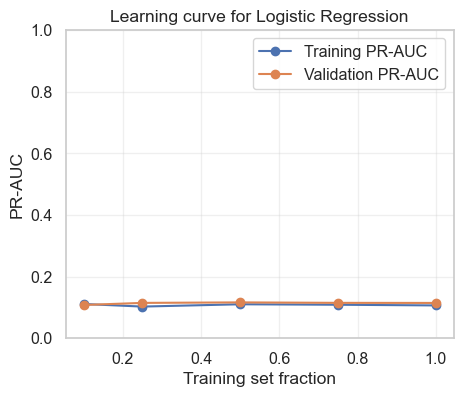

In [30]:
plt.figure(figsize=(5, 4))

plt.plot(
    learning_curve_df["train_fraction"],
    learning_curve_df["train_pr_auc"],
    marker="o",
    label="Training PR-AUC"
)

plt.plot(
    learning_curve_df["train_fraction"],
    learning_curve_df["val_pr_auc"],
    marker="o",
    label="Validation PR-AUC"
)

plt.xlabel("Training set fraction")
plt.ylabel("PR-AUC")
plt.title("Learning curve for Logistic Regression")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()